In [1]:
import pandas as pd
import psycopg2
import requests
import time
import datetime
from collections import Counter 
import re
import random
#import unidecode
import math


# Analyse des EM 

In [2]:
df_clinique = pd.read_csv("Resultats/Excels/patients_FR_geocoded_adulte_clinique_patho.csv",sep=";", dtype={"codepost":str})
print(len(df_clinique))

pathologies = df_clinique.patho.unique().tolist()
del(pathologies[-1])

## Medical event 
df_ap = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/aplasie.xlsx")
df_ep = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/ep.xlsx")
df_ins = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/ins_surrenale.xlsx")
df_ira = pd.read_excel("../geocodeur/from_hegp//data/data_octobre_2023/medical_event/ira.xlsx")
df_mtev = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/mtev.xlsx")
df_pneumo = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/pneumopathie.xlsx")

df_mtev_ep = pd.concat([df_ep,df_mtev])
dict_em = {
    "ap" : df_ap,
    "ep_mtev" : df_mtev_ep,
    "ins" : df_ins,
    "ira" : df_ira, 
    "pneumo" : df_pneumo
}
evenement = ["ap", "ep_mtev","ins", "ira","pneumo"]

57878


In [30]:
nb_patients_patho = {}
for patho in pathologies: 

    df_patho = df_clinique[df_clinique["patho"]==patho]
    nb_patients_patho[patho] = len(df_patho)

nb_patients_patho


{'Hemato': 2120,
 'Ophtalmo': 4176,
 'Uro': 5319,
 'ORL': 1468,
 'Sein': 34638,
 'Gastro': 1912,
 'Gynéco': 2356,
 'Sarcome': 1461,
 'Dermato': 1007,
 'Thorax': 1770,
 'Neuro': 543,
 'Autre': 182}

In [4]:
for nom_df in dict_em : 
    df = dict_em[nom_df]
    df_no_duplicates = df.drop_duplicates(subset="pseudo_provisoire", keep="first")
    dict_em[nom_df] = df_no_duplicates

### Emevenement medicaux en fct de la localisation du cancer 

In [5]:
res_em_patho = {}

df_em_patho = pd.DataFrame(columns = ["index","pathologie", "EM","count"])
i = 0
for em in dict_em : 
    df_em = dict_em[em]
    id_em = df_em["pseudo_provisoire"].unique()

    for patho in pathologies : 
        df_patho = df_clinique[df_clinique["patho"]==patho]
        
        df_even_patho = df_patho[df_patho['pseudo_provisoire'].isin(id_em)]

        count_em_patho = len(df_even_patho)

        df_em_patho.at[i,"index"] = i
        df_em_patho.at[i,"pathologie"] = patho 
        df_em_patho.at[i,"EM"] = em
        df_em_patho.at[i,'count'] = count_em_patho
        i +=1

df_em_patho

,index,pathologie,EM,count
0,0,Hemato,ap,181
1,1,Ophtalmo,ap,0
2,2,Uro,ap,10
3,3,ORL,ap,13
4,4,Sein,ap,155
5,5,Gastro,ap,17
6,6,Gynéco,ap,26
7,7,Sarcome,ap,25
8,8,Dermato,ap,1
9,9,Thorax,ap,42


In [6]:
# len(df_clinique[df_clinique['patho']=="Autre"])
# df_count.pathologie.unique()

In [7]:
df_count = df_em_patho.groupby(['pathologie','EM']).sum().reset_index()

df_count[df_count['pathologie']=="Autre"]

,pathologie,EM,index,count
0,Autre,ap,11,3
1,Autre,ep_mtev,23,1
2,Autre,ins,35,0
3,Autre,ira,47,2
4,Autre,pneumo,59,0


#### Histo visu 

In [8]:
df_ap = df_count[df_count['EM']=="pneumo"]

In [9]:
import plotly.express as px

fig = px.bar(df_ap.sort_values('count',ascending=False), x="pathologie", y="count") #, barmode="group"

fig.update_layout(title="Nombre de patient ayant eu une pneumopathie en fonction de la localisation du cancer")
fig.show()

### Normalisation pour 1000 patients

In [10]:
total_patients = 1000
df_em_patho['normalized_count'] = (df_em_patho['count']/total_patients) *100 

In [11]:
import plotly.express as px

fig = px.bar(df_em_patho, x="pathologie", y="normalized_count", color="EM") #, barmode="group"

fig.update_layout(title="Nombre de d'évènements medicaux en fonction de la localisation du cancer normalisé pour 1000 patients")
fig.show()

In [12]:
resultats_groupby = df_em_patho.groupby(["pathologie","EM"]).sum()
resultats_groupby.to_excel("EM_patho_all.xlsx")
resultats_groupby

index count normalized_count
pathologie EM                                  
Autre      ap         11     3              0.3
           ep_mtev    23     1              0.1
           ins        35     0              0.0
           ira        47     2              0.2
           pneumo     59     0              0.0
Dermato    ap          8     1              0.1
           ep_mtev    20     1              0.1
           ins        32     0              0.0
           ira        44     3              0.3
           pneumo     56     0              0.0
Gastro     ap          5    17              1.7
           ep_mtev    17    89              8.9
           ins        29     1              0.1
           ira        41    48              4.8
           pneumo     53    38              3.8
Gynéco     ap          6    26              2.6
           ep_mtev    18    49              4.9
           ins        30     3              0.3
           ira        42    43              4.3
           pneumo     54    21              2.1
Hemato     ap          0   181             18.1
           ep_mtev    12    27              2.7
           ins        24     2              0.2
           ira        36    46              4.6
           pneumo     48    53              5.3
Neuro      ap         10     7              0.7
           ep_mtev    22     1              0.1
           ins        34     0              0.0
           ira        46     6              0.6
           pneumo     58     1              0.1
ORL        ap          3    13              1.3
           ep_mtev    15    20              2.0
           ins        27     0              0.0
           ira        39    19              1.9
           pneumo     51    47              4.7
Ophtalmo   ap          1     0              0.0
           ep_mtev    13     3              0.3
           ins        25     0              0.0
           ira        37     1              0.1
           pneumo     49     1              0.1
Sarcome    ap          7    25              2.5
           ep_mtev    19    23              2.3
           ins        31     1              0.1
           ira        43    21              2.1
           pneumo     55    23              2.3
Sein       ap          4   155             15.5
           ep_mtev    16   149             14.9
           ins        28     6              0.6
           ira        40    87              8.7
           pneumo     52   127             12.7
Thorax     ap          9    42              4.2
           ep_mtev    21    88              8.8
           ins        33     9              0.9
           ira        45    41              4.1
           pneumo     57   110             11.0
Uro        ap          2    10              1.0
           ep_mtev    14    10              1.0
           ins        26     2              0.2
           ira        38    15              1.5
           pneumo     50    16              1.6

### Calcul du nombre d'occurence des EM en fonction de la localisation de la thumeur

In [13]:
resultats_dict = {}
resultats_patho = []
total_pathologies = []

for patho in pathologies : 
    df_patho = df_clinique[df_clinique["patho"]==patho]
    id_patho = df_patho["pseudo_provisoire"].unique()

    for em in evenement: 

        df_even = dict_em[em]
        df_even_patho = df_even[df_even["pseudo_provisoire"].isin(id_patho)]

    for em in evenement:
        df_even = dict_em[em]
        df_even_patho = df_even[df_even["pseudo_provisoire"].isin(id_patho)]
        count = df_even_patho["pseudo_provisoire"].value_counts().reset_index()
        # count.columns = ["id_patients","occurence"]
        # count["pathologie"] = patho
        # count["evenement_medical"] = em
        # res_name = str(patho)+"_"+str(em)
        # resultats_dict[res_name] = count
        # resultats_patho.append(count)

# resultats = pd.concat(resultats_patho, ignore_index=True)


### Calcul occurence EM par patho et par patients 

In [14]:
resultats_dict = {}
resultats_patho = []
total_pathologies = []
for patho in pathologies : 
    df_patho = df_clinique[df_clinique["patho"]==patho]
    id_patho = df_patho["pseudo_provisoire"].unique()
    total_pathologies.append([patho,len(df_patho)])

    for em in evenement:
        df_even = dict_em[em]
        df_even_patho = df_even[df_even["pseudo_provisoire"].isin(id_patho)]
        count = df_even_patho["pseudo_provisoire"].value_counts().reset_index()
        count.columns = ["id_patients","occurence"]
        count["pathologie"] = patho
        count["evenement_medical"] = em
        res_name = str(patho)+"_"+str(em)
        resultats_dict[res_name] = count
        resultats_patho.append(count)
        
resultats = pd.concat(resultats_patho, ignore_index=True)
resultats

,id_patients,occurence,pathologie,evenement_medical
0,83,1,Hemato,ap
1,21182,1,Hemato,ap
2,21531,1,Hemato,ap
3,22402,1,Hemato,ap
4,22812,1,Hemato,ap
...,...,...,...,...
1729,19256,1,Autre,ap
1730,33402,1,Autre,ap
1731,12241,1,Autre,ep_mtev
1732,31431,1,Autre,ira


### Calcul EM par quartile de revenu 

In [15]:
df_patients_clinique_rev_chom = pd.read_csv("data/data_cleaned/patients_FR_adulte_clinique_revenus_chomage.csv",sep=";")

C:\Users\lpokambo\AppData\Local\Temp\ipykernel_18896\3016372020.py:1: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



In [16]:
df_cim = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/CODECIM_updated.csv.xlsx")
df_cim.drop('Unnamed: 3', axis=1, inplace=True)

correspondance = df_cim.set_index('topo_initiale_cim10')['Proposition_Clémence_1'].to_dict()

df_patients_clinique_rev_chom['pathologie'] = df_patients_clinique_rev_chom['topo_initiale_cim10'].map(correspondance)



### normalisation pour 1000 patients 

In [17]:
stats_par_pathologie = df_patients_clinique_rev_chom[["pathologie","DISP_MED20"]].groupby('pathologie').describe().reset_index()

In [18]:
stats_par_pathologie = df_patients_clinique_rev_chom.groupby('pathologie')["DISP_MED20"].agg(['mean','std']).reset_index()

stats_par_pathologie.columns

Index(['pathologie', 'mean', 'std'], dtype='object')

In [19]:
df_norm = pd.merge(df_patients_clinique_rev_chom,stats_par_pathologie, on ="pathologie",how="left" )

df_norm["revenu_norm"] = (df_norm["DISP_MED20"] - df_norm["mean"])/ df_norm["std"]

df_norm.columns

Index(['Unnamed: 0', 'pseudo_provisoire', 'adresse', 'codepost',
       'nom_commune_postal', 'requete', 'x', 'y', 'score', 'trust_score',
       'street', 'city', 'pc_city', 'ic_city', 'code_dept', 'dept', 'reg',
       'address', 'address_has_num_init', 'address_has_num_geoloc',
       'same_city', 'hostel', 'hosted', 'date_geoloc', 'geometry', 'CODE_IRIS',
       'INSEE_REG', 'CODE_DEPT', 'patient_sexe', 'date_naissance', 'centre',
       'ageaudiag', 'cancernum', 'date_diag', 'topo_initiale_cim10',
       'topo_initialelib', 'IRIS_x', 'DISP_MED20', 'quartile_revenu', 'IRIS_y',
       'P20_ACT1564', 'P20_CHOM1564', 'P20_taux_CHOM1564', 'quartile_chomage',
       'pathologie', 'mean', 'std', 'revenu_norm'],
      dtype='object')

In [20]:
fig = px.histogram(df_norm, x='revenu_norm', color='pathologie',
                   marginal='violin', # ou 'box', 'rug'
                #    hover_data=df.columns, # Afficher toutes les données en survol
                   barmode='overlay', # Superposer les barres de différentes pathologies
                   nbins=30, # Nombre de barres/bin dans l'histogramme
                   opacity=0.75, # Transparence des barres
                   title='Distribution des Revenus Normalisés par Pathologie')

fig.update_layout(xaxis_title='Revenu Normalisé',
                  yaxis_title='Nombre de Patients',
                  legend_title='Pathologie')

fig.show()


In [21]:
# fig = px.bar(df_em_patho, x="pathologie", y="normalized_count", color="EM") #, barmode="group"

# fig.update_layout(title="Nombre de d'évènements medicaux en fonction de la localisation du cancer normalisé pour 1000 patients")
# fig.show()

In [22]:
quartile = df_patients_clinique_rev_chom.quartile_revenu.unique().tolist()

resultats_dict = {}
resultats_quart_rev = []
total_quartiles =[]
for quart in quartile : 
    df_quartile = df_patients_clinique_rev_chom[df_patients_clinique_rev_chom["quartile_revenu"]==quart]
    id_quart = df_quartile["pseudo_provisoire"].unique()
    total_quartiles.append([quart,len(df_quartile)])

    for em in evenement:
        df_even = dict_em[em]
        df_even_quart = df_even[df_even["pseudo_provisoire"].isin(id_quart)]
        count = df_even_quart["pseudo_provisoire"].value_counts().reset_index()
        count.columns = ["id_patients","occurence"]
        count["Quartile"] = "Q"+str(quart+1)
        count["evenement_medical"] = em
        res_name = 'Q'+str(quart+1)+"_"+str(em)
        resultats_dict[res_name] = count
        resultats_quart_rev.append(count)
        
resultats = pd.concat(resultats_quart_rev, ignore_index=True)

In [23]:
resultats.columns

Index(['id_patients', 'occurence', 'Quartile', 'evenement_medical'], dtype='object')

In [24]:
## Calcul % evenement ep pour l'ensemble des patients traités pour gynéco 
resultats_groupby = resultats.groupby(["Quartile","evenement_medical"]).sum()
# resultats_groupby

## Calcul EM par quartile de chomage 

In [25]:
quartile = df_patients_clinique_rev_chom.quartile_chomage.unique().tolist()

resultats_dict = {}
resultats_quart_rev = []
total_quartiles =[]
for quart in quartile : 
    df_quartile = df_patients_clinique_rev_chom[df_patients_clinique_rev_chom["quartile_chomage"]==quart]
    id_quart = df_quartile["pseudo_provisoire"].unique()
    total_quartiles.append([quart,len(df_quartile)])

    for em in evenement:
        df_even = dict_em[em]
        df_even_quart = df_even[df_even["pseudo_provisoire"].isin(id_quart)]
        count = df_even_quart["pseudo_provisoire"].value_counts().reset_index()
        count.columns = ["id_patients","occurence"]
        count["Quartile"] = "Q"+str(quart+1)
        count["evenement_medical"] = em
        res_name = 'Q'+str(quart+1)+"_"+str(em)
        resultats_dict[res_name] = count
        resultats_quart_rev.append(count)
        
resultats = pd.concat(resultats_quart_rev, ignore_index=True)

In [26]:
resultats.columns

Index(['id_patients', 'occurence', 'Quartile', 'evenement_medical'], dtype='object')

In [27]:
print(total_quartiles)
resultats_groupby = resultats.groupby(["Quartile","evenement_medical"]).sum()
resultats_groupby

[[1.0, 16371], [2.0, 12145], [3.0, 9233], [0.0, 7819]]


id_patients  occurence
Quartile evenement_medical                        
Q1.0     ap                      750925         44
         ep_mtev                1289531         51
         ins                      61092          2
         ira                    1163207         48
         pneumo                 1135976         47
Q2.0     ap                     3550047        161
         ep_mtev                3770231        161
         ins                     221384          9
         ira                    2280471        106
         pneumo                 3535099        156
Q3.0     ap                     2355520        113
         ep_mtev                2213780         94
         ins                      68215          3
         ira                    1894669         76
         pneumo                 2413471        102
Q4.0     ap                     1755083         85
         ep_mtev                1818090         80
         ins                      50522          3
         ira                    1393602         59
         pneumo                 1671851         74

## Visualisation des résultats

In [28]:
df_patho.columns

Index(['Unnamed: 0', 'pseudo_provisoire', 'adresse', 'codepost',
       'nom_commune_postal', 'requete', 'x', 'y', 'score', 'trust_score',
       'street', 'city', 'pc_city', 'ic_city', 'code_dept', 'dept', 'reg',
       'address', 'address_has_num_init', 'address_has_num_geoloc',
       'same_city', 'hostel', 'hosted', 'date_geoloc', 'geometry', 'CODE_IRIS',
       'INSEE_REG', 'CODE_DEPT', 'patient_sexe', 'date_naissance', 'centre',
       'ageaudiag', 'cancernum', 'date_diag', 'topo_initiale_cim10',
       'topo_initialelib', 'patho'],
      dtype='object')

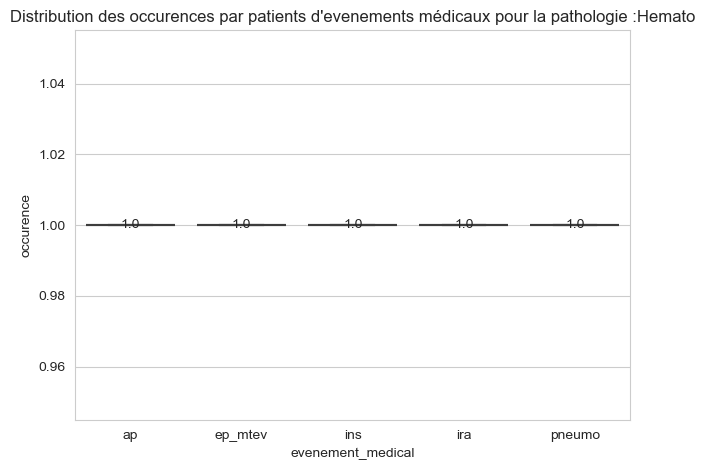

In [29]:
import seaborn as sns 

patho = pathologies[0]

#df_patho = resultats[resultats["pathologie"]==patho]


sns.set_style("whitegrid")


box_plot = sns.boxplot(x= "evenement_medical", y ="occurence",data=resultats)
box_plot.set(title=f"Distribution des occurences par patients d'evenements médicaux pour la pathologie :{patho}")

ax = box_plot.axes
lines = ax.get_lines()
categories = ax.get_xticks()

for cat in categories:
    y = round(lines[4+cat*6].get_ydata()[0],1)
    ax.text(
        cat,
        y,
        f'{y}',
        ha = 'center',
        va = 'center'
    )

box_plot.figure.tight_layout()